## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [2]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
#pip install ucimlrepo

In [34]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [35]:
# dataset structure and summary statistics
print("Dataset shape (features):", X.shape)
print("Target shape:", y.shape)

print("\n--- Features Head ---")
print(X.head())
print("\n--- Target Head ---")
print(y.head())

# Summary statistics of numeric predictors
print("\n--- Feature Summary ---")
print(X.describe().T)

Dataset shape (features): (517, 12)
Target shape: (517, 1)

--- Features Head ---
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0

--- Target Head ---
   area
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0

--- Feature Summary ---
      count        mean         std   min    25%    50%    75%    max
X     517.0    4.669246    2.313778   1.0    3.0    4.0    7.0    9.0
Y     517.0    4.299807    1.229900   2.0    4.0    4.0    5.0    9.0
FFMC  517.0   90.644681    5.520111  18.7   90.2   91.6   92.9   96.2
DMC   517.0  110.872340   64.046482   1.1   68.6  108.3  142.4  291.3
DC    517.0  547.940039  248.066192   7.9  437.7  664.2  713.9  860.6
ISI   517.0   

In [36]:
# =========================================

import numpy as np
import pandas as pd

df_full = X.copy()
df_full["area"] = y["area"]

df_full["log_area"] = np.log1p(df_full["area"])

month_map = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
             "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}
day_map   = {"mon":1,"tue":2,"wed":3,"thu":4,"fri":5,"sat":6,"sun":7}

df_full["month_num"] = df_full["month"].map(month_map)
df_full["day_num"]   = df_full["day"].map(day_map)

num_df = df_full.select_dtypes(include=[np.number])

corr_matrix = num_df.corr()

print("\n--- Correlations with log_area ---")
print(corr_matrix["log_area"].sort_values(ascending=False))




--- Correlations with log_area ---
log_area     1.000000
area         0.524134
month_num    0.114280
DMC          0.067153
wind         0.066973
DC           0.066360
X            0.061995
temp         0.053487
FFMC         0.046799
Y            0.038838
rain         0.023311
day_num      0.000208
ISI         -0.010347
RH          -0.053662
Name: log_area, dtype: float64


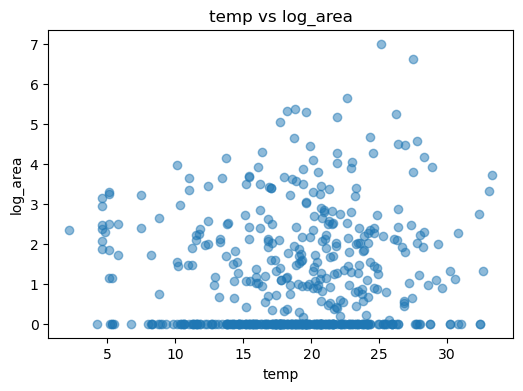

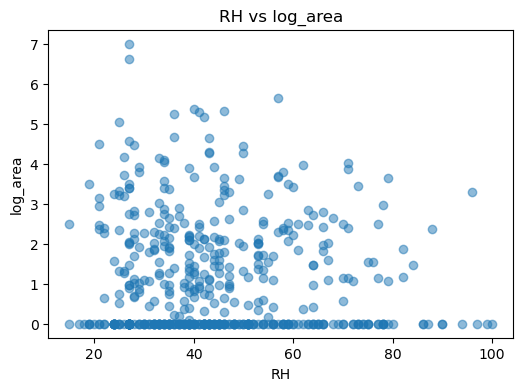

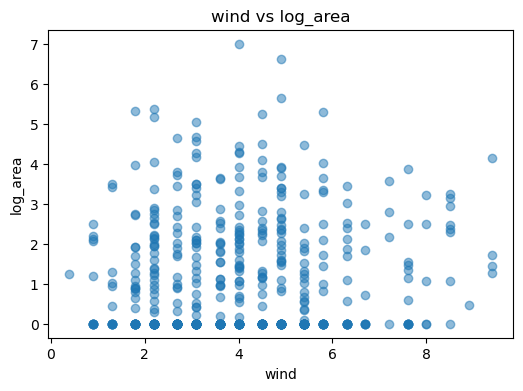

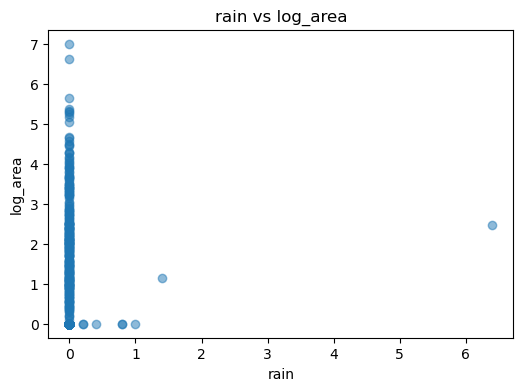

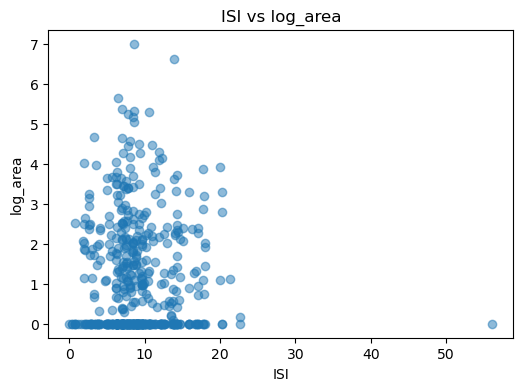

In [37]:
import matplotlib.pyplot as plt

key_predictors = ["temp", "RH", "wind", "rain", "ISI"]

# scatterplots
for col in key_predictors:
    plt.figure(figsize=(6,4))
    plt.scatter(df_full[col], df_full["log_area"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("log_area")
    plt.title(f"{col} vs log_area")
    plt.show()

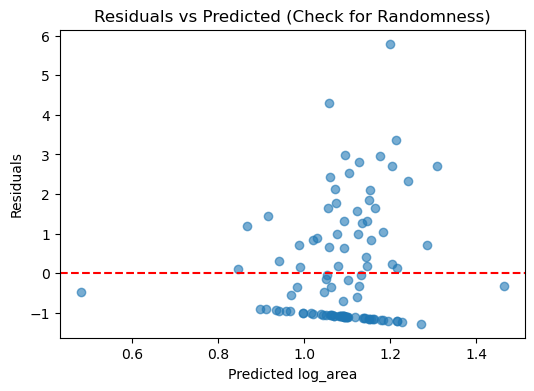

Residuals mean (should be close to 0): 0.0504


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_simple = df_full[["temp", "RH", "wind", "rain", "ISI"]]
y_simple = df_full["log_area"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")  # reference line at 0
plt.xlabel("Predicted log_area")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Check for Randomness)")
plt.show()

print("Residuals mean (should be close to 0):", round(residuals.mean(), 4))


### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_reg = df_full[["temp", "RH", "wind", "rain", "ISI"]]
y_reg = df_full["log_area"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline Multiple Linear Regression")
print("Intercept:", linreg.intercept_)
print("Coefficients:", linreg.coef_)
print("Predictors:", list(X_reg.columns))
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")


Baseline Multiple Linear Regression
Intercept: 0.7968255104306763
Coefficients: [ 0.01504719 -0.00012855  0.03753149  0.12449819 -0.01418258]
Predictors: ['temp', 'RH', 'wind', 'rain', 'ISI']
RMSE: 1.4622
R^2: 0.0273


In [39]:
from sklearn.preprocessing import PolynomialFeatures

# predictors
X_reg = df_full[["temp", "RH", "wind", "rain", "ISI"]]
y_reg = df_full["log_area"]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_reg)

poly_features = poly.get_feature_names_out(X_reg.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y_reg, test_size=0.2, random_state=42
)

linreg_poly = LinearRegression()
linreg_poly.fit(X_train, y_train)

y_pred_poly = linreg_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("Multiple Linear Regression with Quadratic Terms")
print("Number of features after expansion:", len(poly_features))
print(f"RMSE: {rmse_poly:.4f}")
print(f"R^2: {r2_poly:.4f}")

coef_df = pd.DataFrame({
    "Feature": poly_features,
    "Coefficient": linreg_poly.coef_
})
print("\n--- First 10 coefficients ---")
print(coef_df.head(10))

Multiple Linear Regression with Quadratic Terms
Number of features after expansion: 20
RMSE: 3.2128
R^2: -3.6965

--- First 10 coefficients ---
     Feature  Coefficient
0       temp    -0.234926
1         RH    -0.032203
2       wind     0.160813
3       rain    54.277802
4        ISI     0.041158
5     temp^2     0.006418
6    temp RH     0.001961
7  temp wind    -0.013565
8  temp rain     0.507914
9   temp ISI    -0.001352


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df_full["temp_wind"] = df_full["temp"] * df_full["wind"]
df_full["temp_RH"]   = df_full["temp"] * df_full["RH"]

X_inter = df_full[["temp", "RH", "wind", "rain", "ISI", "temp_wind", "temp_RH"]]
y_inter = df_full["log_area"]

X_train, X_test, y_train, y_test = train_test_split(
    X_inter, y_inter, test_size=0.2, random_state=42
)

linreg_inter = LinearRegression()
linreg_inter.fit(X_train, y_train)

y_pred_inter = linreg_inter.predict(X_test)
rmse_inter = np.sqrt(mean_squared_error(y_test, y_pred_inter))
r2_inter = r2_score(y_test, y_pred_inter)

print("Regression with Interaction Terms")
print("Coefficients:")
for name, coef in zip(X_inter.columns, linreg_inter.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {linreg_inter.intercept_:.4f}")
print(f"RMSE: {rmse_inter:.4f}, R²: {r2_inter:.4f}")

Regression with Interaction Terms
Coefficients:
  temp: 0.0862
  RH: 0.0011
  wind: 0.3266
  rain: 0.1325
  ISI: -0.0077
  temp_wind: -0.0172
  temp_RH: 0.0001
Intercept: -0.6298
RMSE: 1.4776, R²: 0.0066


In [41]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_all = df_full[["month", "day", "temp", "RH", "wind", "rain", "ISI"]]
y_all = df_full["log_area"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["month", "day"]),
        ("num", "passthrough", ["temp", "RH", "wind", "rain", "ISI"])
    ]
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Regression with Indicator Variables (month/day)")
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

Regression with Indicator Variables (month/day)
RMSE: 1.4962, R²: -0.0185


### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [42]:
import statsmodels.api as sm

X_diag = df_full[["temp", "RH", "wind", "rain", "ISI"]]
y_diag = df_full["log_area"]

X_diag_const = sm.add_constant(X_diag)

ols_model = sm.OLS(y_diag, X_diag_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.346
Date:                Sat, 27 Sep 2025   Prob (F-statistic):              0.243
Time:                        16:23:58   Log-Likelihood:                -903.09
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     511   BIC:                             1844.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7053      0.444      1.588      0.1

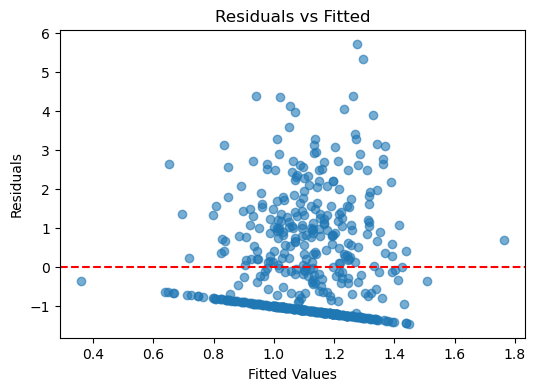

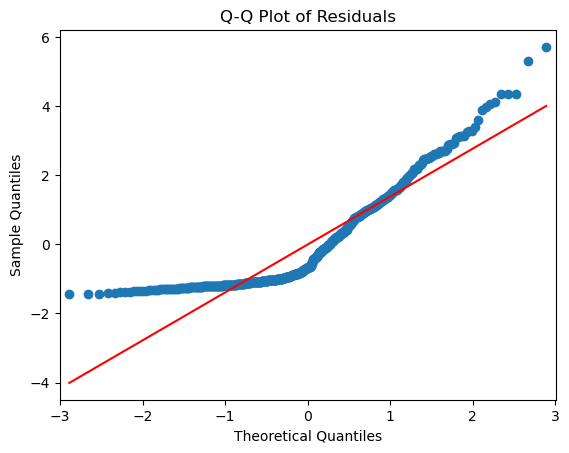

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = ols_model.resid
fitted = ols_model.fittedvalues

# Residuals vs. Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line="s")
plt.title("Q-Q Plot of Residuals")
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [44]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

X_reg = df_full[["temp", "RH", "wind", "rain", "ISI"]]
y_reg = df_full["log_area"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)  # cross-validation to pick alpha
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("Best alpha:", ridge.alpha_)
print("Coefficients:", dict(zip(X_reg.columns, ridge.coef_)))
print(f"MSE: {ridge_mse:.4f}, R²: {ridge_r2:.4f}")

lasso = LassoCV(alphas=[0.01, 0.1, 1.0], cv=5, max_iter=5000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("\nLasso Regression")
print("Best alpha:", lasso.alpha_)
print("Coefficients:", dict(zip(X_reg.columns, lasso.coef_)))
print(f"MSE: {lasso_mse:.4f}, R²: {lasso_r2:.4f}")

Ridge Regression
Best alpha: 10.0
Coefficients: {'temp': 0.081844429503305, 'RH': -0.004026411783163893, 'wind': 0.0639263683116706, 'rain': 0.03939962500222066, 'ISI': -0.05158455174622436}
MSE: 2.1396, R²: 0.0265

Lasso Regression
Best alpha: 1.0
Coefficients: {'temp': 0.0, 'RH': -0.0, 'wind': 0.0, 'rain': 0.0, 'ISI': -0.0}
MSE: 2.1992, R²: -0.0006


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [45]:
threshold = df_full["area"].median()

df_full["HighRisk"] = (df_full["area"] >= threshold).astype(int)

print("Threshold (median area):", threshold)
print(df_full["HighRisk"].value_counts(normalize=True).rename({0:"Low/Medium", 1:"High"}))

Threshold (median area): 0.52
HighRisk
High          0.502901
Low/Medium    0.497099
Name: proportion, dtype: float64


In [46]:
X_clf = df_full[["temp", "RH", "wind", "rain", "ISI"]]
y_clf = df_full["HighRisk"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (413, 5)  Test shape: (104, 5)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("First 5 scaled rows (train):\n", X_train_scaled[:5])

X_train_scaled shape: (413, 5)
First 5 scaled rows (train):
 [[ 0.80081459 -0.71494889  0.24922511 -0.10473816  1.63048148]
 [-1.11105621  0.36862502 -1.76791092 -0.10473816 -0.81154518]
 [ 1.71368983 -0.71494889 -0.03093268 -0.10473816  1.8921272 ]
 [ 0.85248677 -0.29355903 -1.26362691 -0.10473816  1.01997482]
 [-1.42108931  1.93378734 -0.03093268 -0.10473816  0.23503768]]


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
)
threshold = df_full["area"].median()
df_full["HighRisk"] = (df_full["area"] >= threshold).astype(int)
print("HighRisk threshold (median area):", threshold)

#Select predictors
feature_names = ["temp", "RH", "wind", "rain", "ISI"]
X = df_full[feature_names].copy()
y = df_full["HighRisk"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_clf = LogisticRegression(solver="liblinear", random_state=42)
log_clf.fit(X_train_scaled, y_train)

print("\nLogistic Regression Coefficients:")
for name, coef in zip(feature_names, log_clf.coef_[0]):
    print(f"  {name}: {coef:.4f}")
print("Intercept:", round(log_clf.intercept_[0], 4))

y_proba = log_clf.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (HighRisk)
y_pred  = (y_proba >= 0.5).astype(int)                # convert to class with 0.5 threshold

print("\nFirst 5 predicted probabilities (HighRisk):", np.round(y_proba[:5], 4))
print("First 5 predicted classes:", y_pred[:5])


acc  = accuracy_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print("\nPerformance Metrics:")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))

print("\nConfusion Matrix [[TN FP]\n                 [FN TP]]:")
print(cm)

HighRisk threshold (median area): 0.52

Logistic Regression Coefficients:
  temp: 0.1724
  RH: 0.0231
  wind: 0.1507
  rain: -0.1123
  ISI: 0.0057
Intercept: 0.0141

First 5 predicted probabilities (HighRisk): [0.5651 0.4435 0.547  0.5951 0.5041]
First 5 predicted classes: [1 0 1 1 1]

Performance Metrics:
Accuracy: 0.5192
Precision: 0.5192
Recall: 0.5192
F1-score: 0.5192

Confusion Matrix [[TN FP]
                 [FN TP]]:
[[27 25]
 [25 27]]


### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_full[["temp", "RH", "wind", "rain", "ISI"]]

X_vif_const = sm.add_constant(X_vif)

#VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

print("Variance Inflation Factor (VIF) results:")
print(vif_data)

Variance Inflation Factor (VIF) results:
  Feature        VIF
0   const  52.321004
1    temp   1.818211
2      RH   1.447647
3    wind   1.124005
4    rain   1.040127
5     ISI   1.260131


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[When I compared the models, I found that the baseline regression was simple but not very accurate, while adding quadratic and interaction terms made the models more complex and slightly better at explaining fire size. Including indicator variables for month and day and using log transformations helped stabilize the results. Ridge regression handled multicollinearity by shrinking coefficients, while Lasso simplified the model by removing some predictors, though sometimes with a small trade-off in performance. For classification, logistic regression gave reasonable accuracy and was easy to interpret, showing how factors like temperature, wind, and humidity affect fire risk. Overall, there is a trade-off between simplicity, performance, and interpretability, but I would recommend the logistic regression model for classifying high-risk fires because it is straightforward, interpretable, and useful for decision-making, while Ridge regression would be a good choice if predicting exact fire size is needed.]